## Projeto Final da Disciplina de Aprendizagem de Máquina

**Professor:**
Leandro Carlos de Souza

**Alunos:**
* Thiago Ney Evaristo Rodrigues
* Villeneve de Oliveira Soares

### NASA Airfoil Self-Noise Dataset

#### Context

NASA dataset obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel. The data was obtained from [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise).

#### Dataset

The NASA dataset comprises different size [NACA 0012](http://airfoiltools.com/airfoil/details?airfoil=n0012-il) airfoils at various wind tunnel speeds and angles of attack. The span of the airfoil and the observer position were the same in all of the experiments.

This problem has the following inputs:

1. Frequency, in Hertzs. 
2. Angle of attack, in degrees. 
3. Chord length, in meters.
4. Free-stream velocity, in meters per second. 
5. Suction side displacement thickness, in meters. 

The only output is:

6. Scaled sound pressure level, in decibels.

#### Content

- [Imports](#imports)
- [Data Reading](#data-reading)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Data Division](#data-division)
- [Linear Regression](#linear-regression)
- [Decision Tree](#decision-tree)
- [Random Forest](#random-forest)
- [eXtreme Gradient Boosting](#extreme-gradient-boosting)
- [Neural Networks](#neural-networks)
- [Support Vector Machine](#support-vector-machine)
- [Results](#results)

### Imports

In [1]:
import math
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

random_state = 42

/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-11-16 21:50:57.313084: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 21:50:57.363417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:

### Data Reading

In [2]:
df = pd.read_csv(
    "../data/airfoil_self_noise.dat",
    names=[
        "frequency",
        "attack_angle",
        "chord_length",
        "free_stream_velocity",
        "displacement_thickness",  # suction_side_displacement_thickness
        "scaled_sound_pressure",
    ],
    delimiter="\t",
)

display(df)
display(df.describe())
display(df.info())

,frequency,attack_angle,chord_length,free_stream_velocity,displacement_thickness,scaled_sound_pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


,frequency,attack_angle,chord_length,free_stream_velocity,displacement_thickness,scaled_sound_pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   frequency               1503 non-null   int64  
 1   attack_angle            1503 non-null   float64
 2   chord_length            1503 non-null   float64
 3   free_stream_velocity    1503 non-null   float64
 4   displacement_thickness  1503 non-null   float64
 5   scaled_sound_pressure   1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


None

### Exploratory Data Analysis

In [3]:
print(f"Duplicate data: {df.duplicated().sum()}")

Duplicate data: 0


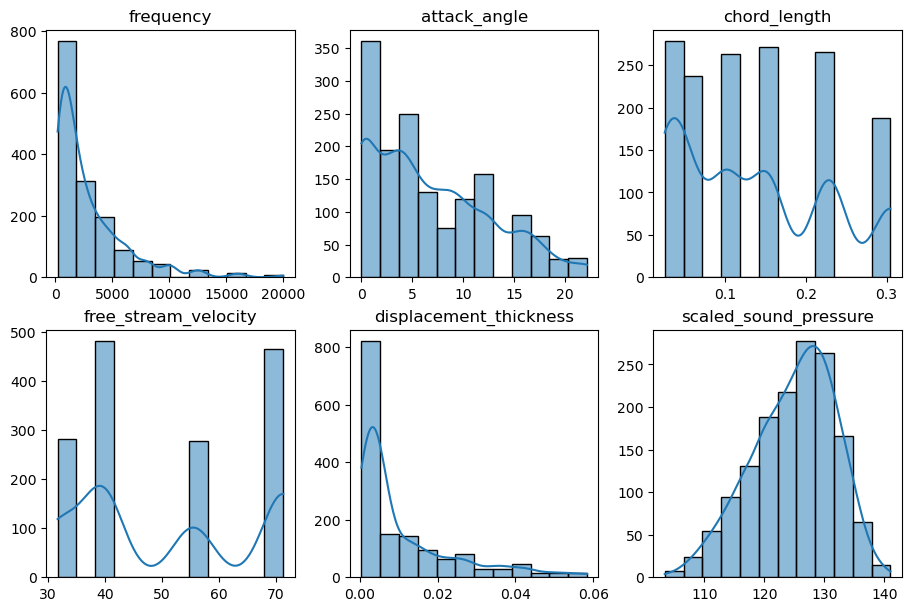

In [4]:
# Auxiliary Function


def sturges_bins(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = len(x)
    if n <= 1:
        return 1, np.inf

    k = math.ceil(math.log2(n)) + 1
    data_range = x.max() - x.min()
    h = data_range / k if data_range > 0 else np.inf
    h = math.ceil(h)

    return k, h


# Plot of Histograms

fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(9, 6), constrained_layout=True)
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    if col != "type":
        data = df[col].values
        k, _ = sturges_bins(data)

        sns.histplot(data=data, bins=k, kde=True, ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")

In [5]:
pt = PowerTransformer(method="yeo-johnson", standardize=True)
df.loc[:, "frequency"] = pt.fit_transform(df[["frequency"]])

/tmp/ipykernel_612312/3753864645.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.68774284 -0.48379184 -0.2791626  ...  0.79826096  1.00700662
  1.22389915]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, "frequency"] = pt.fit_transform(df[["frequency"]])


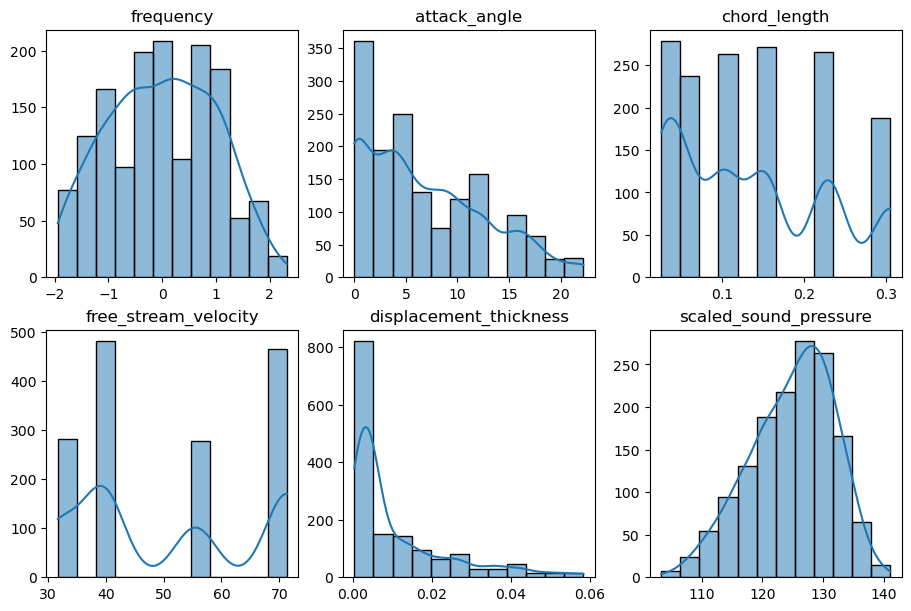

In [6]:
# Plot of Histograms

fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(9, 6), constrained_layout=True)
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    if col != "type":
        data = df[col].values
        k, _ = sturges_bins(data)

        sns.histplot(data=data, bins=k, kde=True, ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")

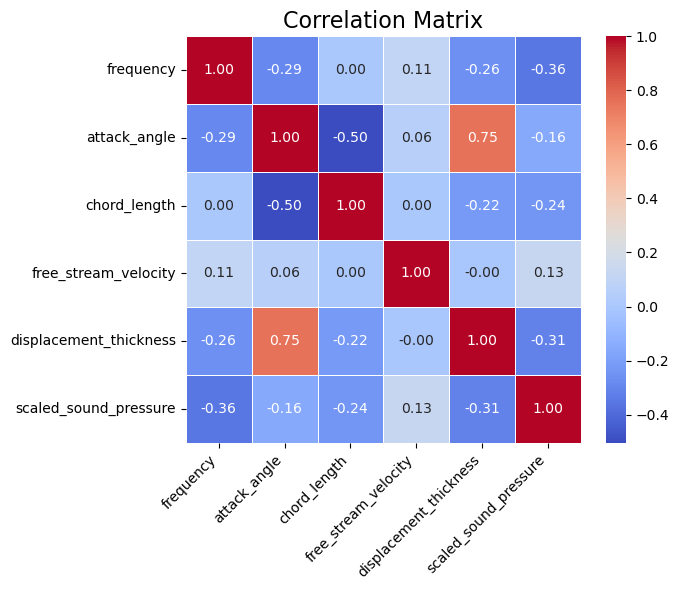

In [7]:
# Correlation Matrix

corr_matrix = df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

### Data Division

In [8]:
input_names = [
    "frequency",
    "attack_angle",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
]

output_names = "scaled_sound_pressure"

scaler = MinMaxScaler()
df_scaler = scaler.fit_transform(df)

X = df_scaler[:, 0:5]
y = df_scaler[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=random_state)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1052, 5), (1052,), (451, 5), (451,))

In [9]:
results = [] # Model, MAE, MSE, R2 Score

### Linear Regression

In [10]:
linear_model = LinearRegression()
linear_model = linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print("Model Performance | Linear Regression")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2score}")

results.append(["Linear Regression", mae, mse, r2score])

Model Performance | Linear Regression
MAE: 0.10373979618388877
MSE: 0.01884382554598256
R2 Score: 0.4355201716613185


In [12]:
for poly_coeff in range(2, 6):
    poly = PolynomialFeatures(poly_coeff)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    linear_model = LinearRegression()
    linear_model = linear_model.fit(X_train_poly, y_train)

    y_pred = linear_model.predict(X_test_poly)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2score = r2_score(y_test, y_pred)

    print(f"Model Performance | Linear Regression - Poly({poly_coeff})")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"R2 Score: {r2score}\n")

    results.append([f"Linear Regression | Poly({poly_coeff})", mae, mse, r2score])

Model Performance | Linear Regression - Poly(2)
MAE: 0.0752664154672164
MSE: 0.009999384955597252
R2 Score: 0.7004615071682561

Model Performance | Linear Regression - Poly(3)
MAE: 0.05684742122458257
MSE: 0.005795310565743358
R2 Score: 0.8263974634376938

Model Performance | Linear Regression - Poly(4)
MAE: 0.043254520403122255
MSE: 0.00344233365933288
R2 Score: 0.8968825142026982

Model Performance | Linear Regression - Poly(5)
MAE: 0.03787246820587183
MSE: 0.0029352836849541927
R2 Score: 0.9120715469072297



### Decision Tree

In [13]:
decision_tree_model = DecisionTreeRegressor(random_state=random_state)

param_grid = {
    "criterion": ["absolute_error", "squared_error", "r2_score"],  # Métricas de divisão
    "max_depth": [1, 2, 5, 10, 20],  # Profundidade máxima
    "min_samples_split": [2, 5, 10, 20, 50],  # Mínimo de amostras para dividir um nó
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],  # Mínimo de amostras em um nó folha
}

grid_search = GridSearchCV(
    estimator=decision_tree_model,  # O modelo a ser otimizado
    param_grid=param_grid,  # A grade de hiperparâmetros
    cv=5,  # Número de folds da validação cruzada
    scoring="neg_mean_squared_error",  # Métrica de avaliação
    n_jobs=-1,  # Usar todos os processadores disponíveis
    verbose=2,
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters")
print(grid_search.best_params_)

decision_tree_model = grid_search.best_estimator_
y_pred = decision_tree_model.predict(X_test)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits


/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarnin

[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=absolute

/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarnin

[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=1, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=a

/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarnin

[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=10, min_samples_split=5; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=5, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=10, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=10, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=10, min_samples_split=50; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=5, min_samples_split=20; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=2, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criter

/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
750 fits failed out of a total of 2250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
53 fits failed with the following error:
Traceback (most recent call last):
  File "/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/base.py", line 471, in _validate_params
    

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print("Model Performance | Decision Tree")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2score}")

results.append(["Decision Tree", mae, mse, r2score])

Model Performance | Decision Tree
MAE: 0.05490285604587107
MSE: 0.006196968479512421
R2 Score: 0.8143655228074871


,Feature,Importance
0,frequency,0.442833
4,displacement_thickness,0.378643
2,chord_length,0.069827
1,attack_angle,0.063645
3,free_stream_velocity,0.045052


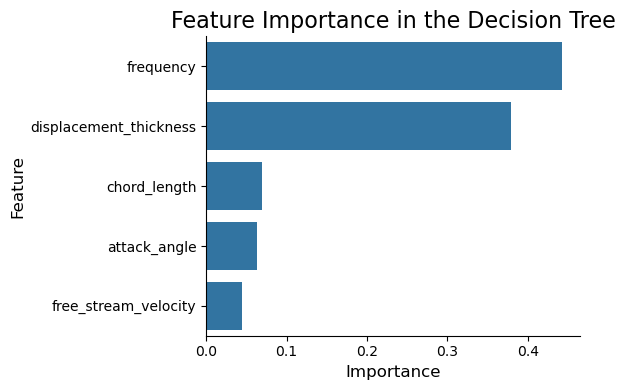

In [15]:
# Get feature importances
importances = decision_tree_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame(
    {"Feature": input_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

display(feature_importance_df)

# Plot the bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance in the Decision Tree", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

### Random Forest

In [16]:
random_forest_model = RandomForestRegressor(random_state=random_state)

param_grid = {
    "n_estimators": [2, 5, 10, 20, 50, 100, 200, 500],  # Número de árvores
    "max_depth": [2, 5, 10, 20, 50, 100, 200],  # Profundidade máxima de cada árvore
    "max_features": ["sqrt", 1.0],  # Número de features a considerar (sqrt, ou todas)
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "min_samples_split": [2, 5, 10, 20, 50],
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters")
print(grid_search.best_params_)

random_forest_model = grid_search.best_estimator_
y_pred = random_forest_model.predict(X_test)

Fitting 5 folds for each of 3360 candidates, totalling 16800 fits
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=2; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=2; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=2; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=2; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=5; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=2; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=5; total time=   0.0s
[CV] END max_depth=2, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=5; total time=   0.0

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print("Model Performance | Random Forest")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2score}")

results.append(["Random Forest", mae, mse, r2score])

Model Performance | Random Forest
MAE: 0.03591090659961189
MSE: 0.002439539543473905
R2 Score: 0.9269219055671442


,Feature,Importance
0,frequency,0.420322
4,displacement_thickness,0.402210
2,chord_length,0.090764
1,attack_angle,0.045103
3,free_stream_velocity,0.041600


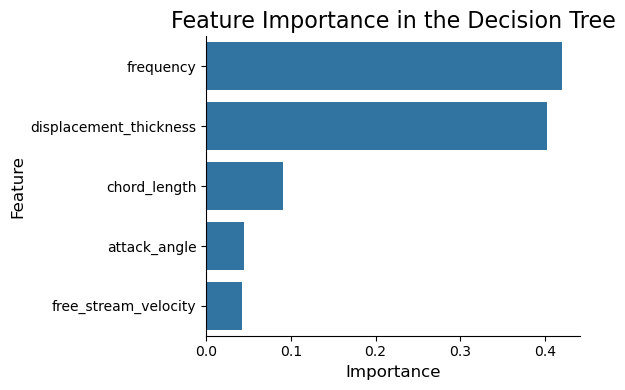

In [18]:
# Get feature importances
importances = random_forest_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame(
    {"Feature": input_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

display(feature_importance_df)

# Plot the bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance in the Decision Tree", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

### eXtreme Gradient Boosting

In [19]:
xgbr_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=random_state)

param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [2, 5, 10, 20],
    "learning_rate": [0.001, 0.01, 0.1],
    "subsample": [0.5, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=xgbr_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=2,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters")
print(grid_search.best_params_)

xgbr_model = grid_search.best_estimator_
y_pred = random_forest_model.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=1.0; total 

/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' v

ators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=5, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=500, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=5, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=500, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=500, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=0.5; total time=   0.2s
[CV] END learning_rate=0.001, max_depth=2, n_estimators=200, subsample=0.8; total time=   0.1s
[CV] 

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print("Model Performance | XGBoost")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2score}")

results.append(["XGBoost", mae, mse, r2score])

Model Performance | XGBoost
MAE: 0.03591090659961189
MSE: 0.002439539543473905
R2 Score: 0.9269219055671442


### Neural Networks

In [21]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(64, activation="relu")(input_)
hidden2 = keras.layers.Dense(128, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(128, activation="relu")(hidden2)
hidden4 = keras.layers.Dense(128, activation="relu")(hidden3)
hidden5 = keras.layers.Dense(64, activation="relu")(hidden4)
output = keras.layers.Dense(1, dtype="float64")(hidden5)

mlp_model = keras.Model(inputs=[input_], outputs=[output])

custom_optimizer = keras.optimizers.Adam(learning_rate=0.0001)
mlp_model.compile(loss="mse", optimizer=custom_optimizer, metrics=["r2_score"])
mlp_model.summary()

I0000 00:00:1763340806.367496  612312 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,049 (195.76 KB)

 Trainable params: 50,049 (195.76 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
checkpoint_filepath = "best_model.keras"

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor="val_r2_score",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
)

history = mlp_model.fit(
    X_train,
    y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    callbacks=[model_checkpoint_callback],
)

mlp_model = load_model(checkpoint_filepath)
y_pred = mlp_model.predict(X_test)

Epoch 1/500


I0000 00:00:1763340808.600912  612929 service.cc:148] XLA service 0x730268003100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763340808.602125  612929 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-11-16 21:53:28.759454: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763340809.088405  612929 cuda_dnn.cc:529] Loaded cuDNN version 90101
2025-11-16 21:53:30.282711: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_500', 68 bytes spill stores, 72 bytes spill loads



32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2341 - r2_score: -5.9615 

I0000 00:00:1763340811.095281  612929 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-11-16 21:53:32.051568: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_500', 24 bytes spill stores, 28 bytes spill loads



33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.1691 - r2_score: -4.0142 - val_loss: 0.0774 - val_r2_score: -1.3184
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0675 - r2_score: -1.0018 - val_loss: 0.0649 - val_r2_score: -0.9451
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0597 - r2_score: -0.7709 - val_loss: 0.0571 - val_r2_score: -0.7107
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0528 - r2_score: -0.5663 - val_loss: 0.0500 - val_r2_score: -0.4981
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0460 - r2_score: -0.3643 - val_loss: 0.0430 - val_r2_score: -0.2874
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0389 - r2_score: -0.1530 - val_loss: 0.0352 - val_r2_score: -0.0546
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0320 - r2_score: 0.0504 - val_loss: 0.0287 - val_r2_score: 0.1399
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 - r2_score: 0.2256 - val_loss: 0.0249 - val_

<Figure size 640x480 with 0 Axes>

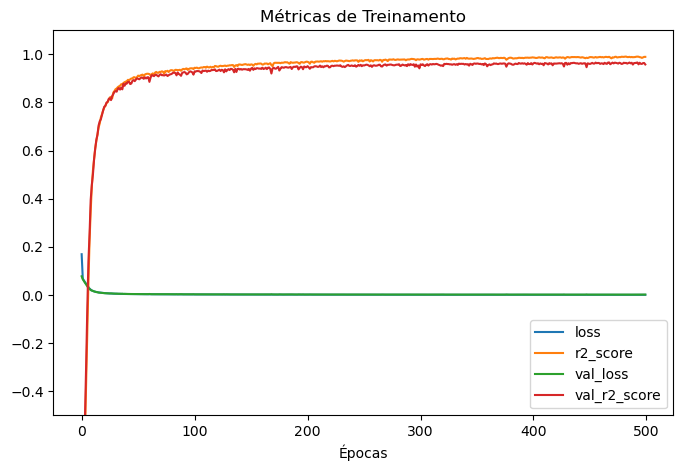

In [23]:
plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.ylim([-0.5, 1.1])
plt.show()

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)

print("Model Performance | Neural Networks")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 Score: {r2score}")

results.append(["Neural Networks", mae, mse, r2score])

Model Performance | Neural Networks
MAE: 0.024460661451476358
MSE: 0.0011366632456130136
R2 Score: 0.9659504662576696


### Results

In [25]:
results = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score"])
results = results.sort_values("R2 Score")
display(results)

,Model,MAE,MSE,R2 Score
0,Linear Regression,0.103740,0.018844,0.435520
1,Linear Regression | Poly(2),0.075266,0.009999,0.700462
5,Decision Tree,0.054903,0.006197,0.814366
2,Linear Regression | Poly(3),0.056847,0.005795,0.826397
3,Linear Regression | Poly(4),0.043255,0.003442,0.896883
4,Linear Regression | Poly(5),0.037872,0.002935,0.912072
6,Random Forest,0.035911,0.002440,0.926922
7,XGBoost,0.035911,0.002440,0.926922
8,Neural Networks,0.024461,0.001137,0.965950
